# Demand Estimation - Part 3: Pricing Analyst

In this section, we use the demand model produced from Part 2 to estimate each brand's costs, markups, and profits.

Average Unit Cost and Markups for Each Brand Over the Years:
              unit_cost     markup
brand                             
chefman       51.709360  39.229052
cosori        76.887975  37.379974
cuisinart    185.142766  38.804327
dash          18.018255  39.460672
gowise usa    45.841720  41.613061
instant_pot   60.972266  43.489087
ninja        101.458295  43.884246
nuwave        99.662834  37.361550
oster        152.664213  36.367071
ultrean       38.939123  39.175483
Average Unit Cost, Price, and Rating for Each Brand
              unit_cost   avg_price  avg_rating
brand                                          
chefman       51.709360   90.938411    4.427966
cosori        76.887975  114.267950    4.656292
cuisinart    185.142766  223.947093    4.438892
dash          18.018255   57.478927    4.476394
gowise usa    45.841720   87.454781    4.576990
instant_pot   60.972266  104.461353    4.559323
ninja        101.458295  145.342541    4.742064
nuwave        99.662834  137.024384

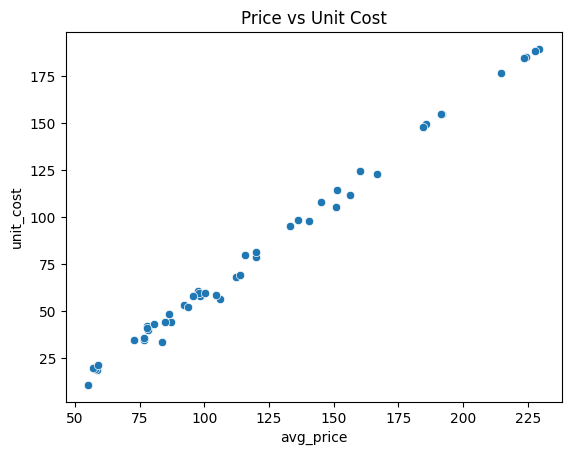

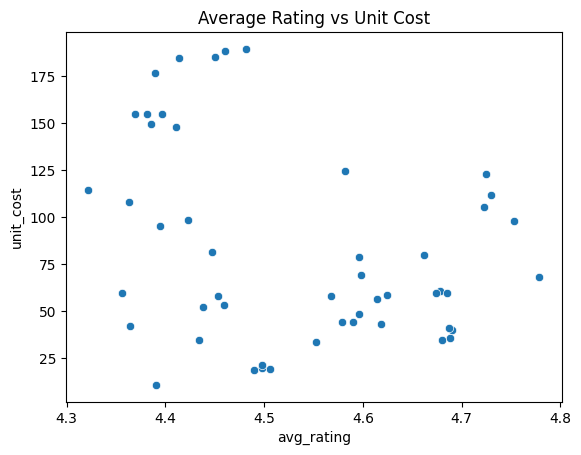

In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

#Question 1 and Question 2
data = pd.read_csv("sample_data/air_fryers_clean_brand_year.csv")
priceCoefficient = -0.0282
data["demand_slope"] = priceCoefficient * data["brand_share"] * (1 - data["brand_share"])
data["unit_cost"] = data["avg_price"] + data["brand_share"] / data["demand_slope"]
data["markup"] = data["avg_price"] - data["unit_cost"]
print("Average Unit Cost and Markups for Each Brand Over the Years:")
print(data.groupby("brand")[["unit_cost", "markup"]].mean())

#Question 3
dataCompare = data.groupby("brand")[["unit_cost", "avg_price", "avg_rating"]].mean()
print("Average Unit Cost, Price, and Rating for Each Brand")
print(dataCompare)
sns.scatterplot(data = data, x = "avg_price", y = "unit_cost")
plt.title("Price vs Unit Cost")
plt.show()
sns.scatterplot(data = data, x = "avg_rating", y = "unit_cost")
plt.title("Average Rating vs Unit Cost")
plt.show()

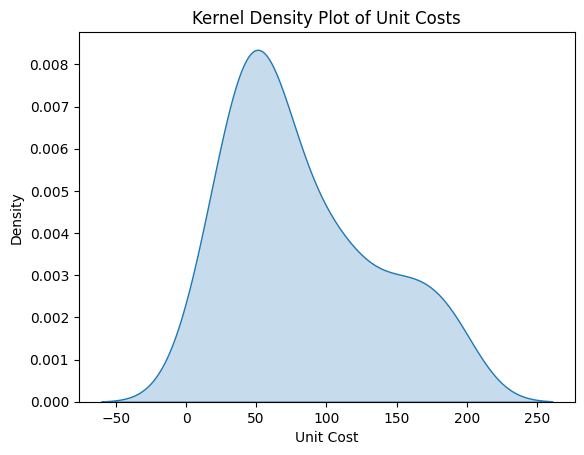

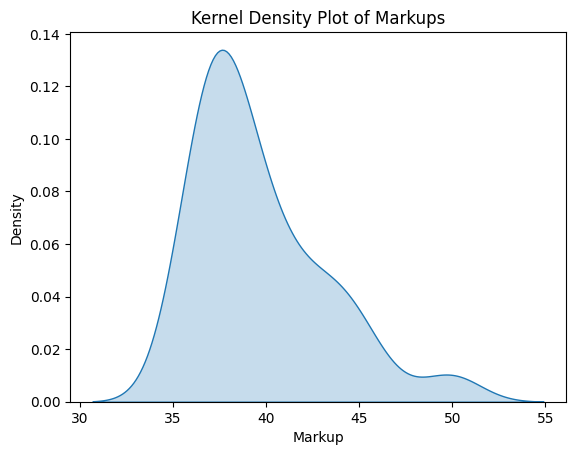

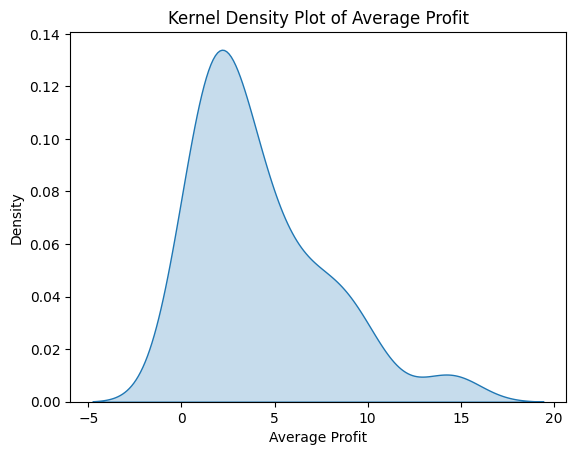

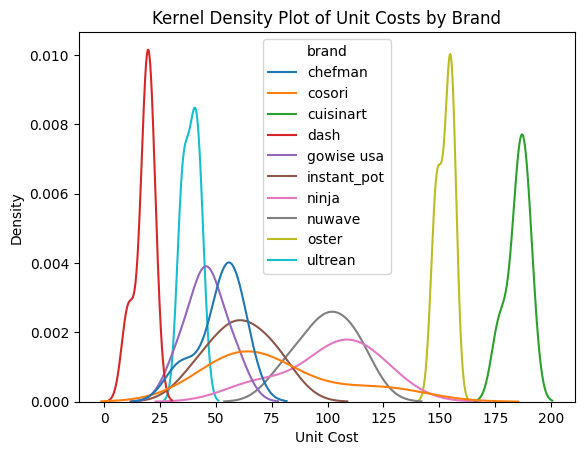

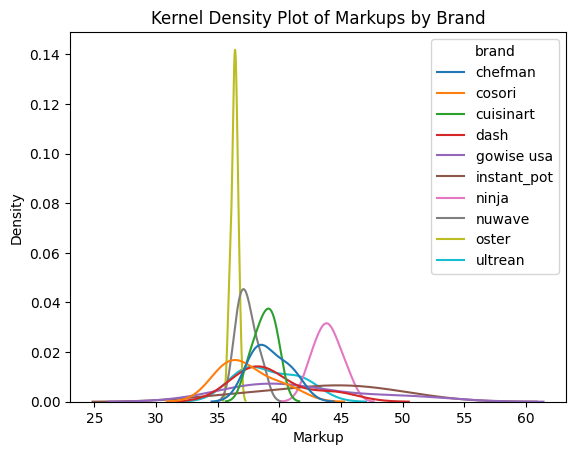

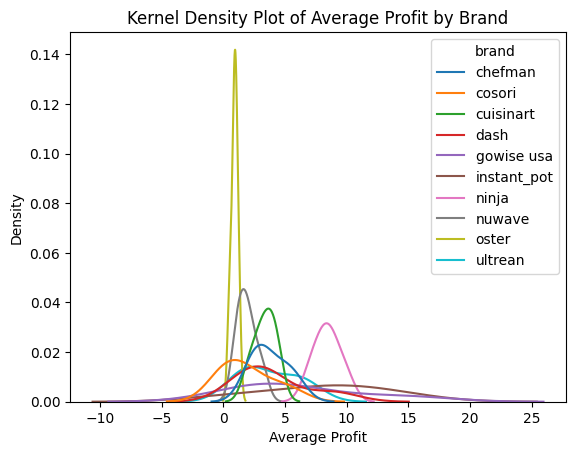

Share-Weighted Average Profit by Brand:
brand
ninja          8.423253
instant_pot    8.028094
gowise usa     6.152068
dash           3.999680
chefman        3.768059
ultrean        3.714490
cuisinart      3.343334
cosori         1.918981
nuwave         1.900557
oster          0.906078
Name: average_profit, dtype: float64


In [4]:
data["average_profit"] = data["brand_share"] * data["markup"]

# Kernel density plots in general
sns.kdeplot(data=data, x="unit_cost", fill=True)
plt.title("Kernel Density Plot of Unit Costs")
plt.xlabel("Unit Cost")
plt.show()

sns.kdeplot(data=data, x="markup", fill=True)
plt.title("Kernel Density Plot of Markups")
plt.xlabel("Markup")
plt.show()

sns.kdeplot(data=data, x="average_profit", fill=True)
plt.title("Kernel Density Plot of Average Profit")
plt.xlabel("Average Profit")
plt.show()

# Kernel density plots by brand
sns.kdeplot(data=data, x="unit_cost", hue="brand", fill=False)
plt.title("Kernel Density Plot of Unit Costs by Brand")
plt.xlabel("Unit Cost")
plt.show()

sns.kdeplot(data=data, x="markup", hue="brand", fill=False)
plt.title("Kernel Density Plot of Markups by Brand")
plt.xlabel("Markup")
plt.show()

sns.kdeplot(data=data, x="average_profit", hue="brand", fill=False)
plt.title("Kernel Density Plot of Average Profit by Brand")
plt.xlabel("Average Profit")
plt.show()

# Highest share-weighted average profit by brand
profit_summary = data.groupby("brand")["average_profit"].mean().sort_values(ascending=False)

print("Share-Weighted Average Profit by Brand:")
print(profit_summary)

#### Question 1)
* Highest Average Unit Cost: Cuisinart (185.14 dollars), Oster (152.66 dollars), and Ninja (101.46 dollars)
* Lowest Average Unit Cost: Dash (18.02 dollars), Ultrean (38.94 dollars), and Gowise USA (45.84 dollars)
* Highest Average Markup: Ninja (43.88 dollars), Instant Pot (43.49 dollars), and Gowise USA (41.61 dollars)
* Lowest Average Markup: Oster (36.37 dollars), Nuwave (37.36 dollars), and Cosori (37.38 dollars)
* Based on the data, premium brands tend to have higher average unit costs while Ninja and Instant Pot have the highest average markups.

#### Question 2)
* No inferred unit costs are negative indicating that our model is producing realistic cost estimates. If there had been negative inferred unit costs that would mean a brand is making the product for less than \$0, which would indicate that our model produced an unrealistic cost estimate.

#### Question 3)
* The Cuisinart (185.14 dollars), Oster (152.66 dollars), and Ninja (101.46 dollars) brands have the highest average unit costs. Average unit cost and average ratings do not have a clear direct relationship. Low cost brands like Ultrean and Cosori have high ratings while a high cost brand like Ninja also has high ratings. Other high cost brands like Oster have lower ratings than some low cost brands.
* The Price vs Unit Cost scatterplot indicates a clear direct relationship, revealing that as price increases unit cost increases.
* The Average Rating vs Unit Cost scatterplot does not indicate a clear relationship, with values being spread out and lacking any clear pattern.
* Based on the data, more expensive products do not necessarily have higher consumer satisfaction. The Average Rating vs Unit Cost scatterplot illustrates a lack of a relationship between the variables, revealing that higher consumer satisfaction is not directly tied to just higher cost brands, but can be found in lower cost brands as well. The same is true for lower consumer ratings, with these being present in high and low cost brands.

#### Question 4)
The kernel density plots show that unit costs are more spread out than markups. The unit cost plot has most values around the lower-to-middle range, but it also extends far to the right because some brands have much higher inferred costs. This matches the brand-level results where Cuisinart, Oster, and Ninja had the highest average unit costs.

The markup KDE plot is more concentrated, with most markups falling around the high 30s to low 40s. This means that even though brands have different prices and different inferred costs, their markups are not as spread out as their unit costs.

The average profit KDE plot is concentrated mostly between about 0 and 10, with a smaller right tail. This makes sense because average profit is calculated as brand_share × markup, so it depends on both the markup and the brand’s share of the market.

When looking at the KDE plots by brand, the unit cost plot shows clearer separation between brands than the markup plot. Dash and Ultrean are concentrated at lower unit costs, while Cuisinart and Oster are concentrated at much higher unit costs. For markups and average profit, Ninja and Instant Pot stand out more because they have stronger profitability measures.

#### Question 5)
The brands with the highest share-weighted average profit are Ninja, Instant Pot, and Gowise USA. Ninja has the highest average profit at about 8.42, followed by Instant Pot at about 8.03 and Gowise USA at about 6.15. These brands are the most profitable in this cleaned market based on the share-weighted profit index.

This result is different from only looking at unit cost or markup. For example, Cuisinart and Oster have some of the highest unit costs, but they do not have the highest share-weighted average profit. Oster actually has the lowest average profit at about 0.91. This shows that a brand’s profitability depends not only on its price or cost, but also on its markup and market share. Ninja and Instant Pot perform well because they combine relatively high markups with stronger brand shares.